# 20 · Working with real data files

In the other notebooks the data were generated in the code. Real work starts with a **file** - from a
data logger, an instrument, a colleague or a public archive - and files have headers, units, missing
values, error codes, gaps and inconsistencies. This notebook works through three files:

1. a NIST reference measurement (**real** ultrasonic-calibration data with certified results),
2. the Mauna Loa CO₂ record (**real**, 1958-2026, with a trap in its header),
3. a messy process-logger file (synthetic, so that the cleaning can be checked).

All three ship with `engmath`: `datasets.path(name)` gives a file's location on your computer, and from
there you read it exactly as you would read your own files.

**What you will learn**

- inspect a data file before loading it, and read it with NumPy and pandas
- detect silent problems such as mismatched headers, unit changes and error codes
- clean a messy file step by step with a record of every change
- analyse real records: reproduce a certified NIST fit; trend and seasonal cycle of CO₂

**Before you start:** notebooks 00, 08, 09 and 16; basic pandas is introduced here  ·  **Time:** about 75-90 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
import pandas as pd
from engmath import datasets, fitting, fourier

## Rule 1: look at the file before loading it

In [2]:
path = datasets.path("Chwirut2.dat")
with open(path, encoding="utf-8") as fh:
    lines = fh.readlines()
print(f"{len(lines)} lines. The start of the file:")
print("".join(lines[:16]))
print("... and the data section:")
print("".join(lines[58:64]))

114 lines. The start of the file:
NIST/ITL StRD
Dataset Name:  Chwirut2          (Chwirut2.dat)

File Format:   ASCII
               Starting Values   (lines 41 to  43)
               Certified Values  (lines 41 to  48)
               Data              (lines 61 to 114)

Procedure:     Nonlinear Least Squares Regression

Description:   These data are the result of a NIST study involving
               ultrasonic calibration.  The response variable is
               ultrasonic response, and the predictor variable is
               metal distance.



... and the data section:

Data:  y             x
      92.9000E0     0.500E0
      57.1000E0     1.000E0
      31.0500E0     1.750E0
      11.5875E0     3.750E0



The file documents itself: 60 lines of description (including NIST's certified answer), then two
columns - response first, then the predictor. Knowing that, `np.loadtxt` reads it in one line:

shape (54, 2); x from 0.5 to 6.0; y from 3.75 to 92.9
b1 = 1.6657666430e-01   NIST certified 1.6657666537e-01
b2 = 5.1653291162e-03   NIST certified 5.1653291286e-03
b3 = 1.2150007131e-02   NIST certified 1.2150007096e-02


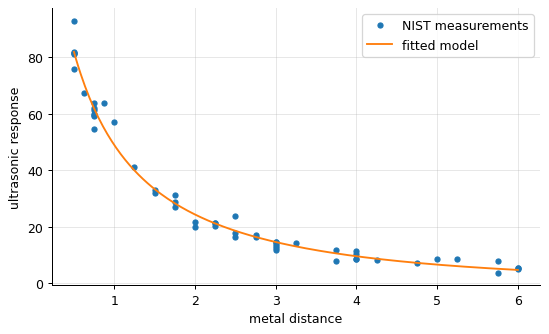

In [3]:
data = np.loadtxt(path, skiprows=60)
y, x = data[:, 0], data[:, 1]                           # ultrasonic response, metal distance
print(f"shape {data.shape}; x from {x.min()} to {x.max()}; y from {y.min()} to {y.max()}")
fit = fitting.levenberg_marquardt(lambda x, b1, b2, b3: np.exp(-b1*x) / (b2 + b3*x), x, y, [0.1, 0.01, 0.02])
certified = [1.6657666537e-01, 5.1653291286e-03, 1.2150007096e-02]    # copied from lines 41-43 of the file
for name, b, c in zip(("b1", "b2", "b3"), fit.coef, certified):
    print(f"{name} = {b:.10e}   NIST certified {c:.10e}")
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(x, y, "o", ms=4, label="NIST measurements")
plt.plot(xx, np.exp(-fit.coef[0]*xx) / (fit.coef[1] + fit.coef[2]*xx), label="fitted model")
plt.xlabel("metal distance"); plt.ylabel("ultrasonic response"); plt.legend(); plt.show()

Reading the real file and fitting it reproduces NIST's certified parameters to about eight significant
digits - far more than the measurement precision can justify, and a good check that both the file
reading and the fitting code are right.

## Rule 2: never trust a header blindly
The Mauna Loa CO₂ record is one of the most important measurement series in science. Load it the
obvious way:

In [4]:
co2_path = datasets.path("co2_mauna_loa_monthly.csv")
naive = pd.read_csv(co2_path)
print(naive.head(3))

              Date  Decimal Date  Average  Interpolated  Trend  Number of Days
1958-03  1958.2027        315.71   314.44            -1  -9.99           -0.99
1958-04  1958.2877        317.45   315.16            -1  -9.99           -0.99
1958-05  1958.3699        317.51   314.69            -1  -9.99           -0.99


It looks plausible - but look closely. The header names **6** columns, while every row holds **7**
values. pandas silently turned the first value (the date) into the row *index* and shifted every label
by one column: the column called "Average" really holds the *de-seasonalised* values, and "Decimal Date"
holds the monthly means. No error, no warning - just wrong data under plausible names.

In [5]:
with open(co2_path, encoding="utf-8") as fh:
    header, first = fh.readline().strip(), fh.readline().strip()
print("header:", header.split(","), f"({len(header.split(','))} names)")
print("row:   ", first.split(","), f"({len(first.split(','))} values)")

header: ['Date', 'Decimal Date', 'Average', 'Interpolated', 'Trend', 'Number of Days'] (6 names)
row:    ['1958-03', '1958.2027', '315.71', '314.44', '-01', '-9.99', '-0.99'] (7 values)


Comparing with the documentation of NOAA's monthly file, the seven values are: date, decimal date,
monthly mean, de-seasonalised mean, number of measurement days, standard deviation of the days and
uncertainty of the monthly mean, with -1, -9.99 and -0.99 marking values that were not recorded. So we
name the columns ourselves:

In [6]:
cols = ["date", "decimal_year", "co2_ppm", "deseasonalised_ppm", "days", "sd_days", "unc_mean"]
co2 = pd.read_csv(co2_path, header=0, names=cols)
print(co2.head(3)); print("...")
print(co2.tail(2))
print(f"\n{len(co2)} months; months without a day count (-1): {(co2.days < 0).sum()}; "
      f"missing monthly means: {co2.co2_ppm.isna().sum()}")
print("consecutive months, no gaps:", np.allclose(np.diff(co2.decimal_year), 1/12, atol=0.01))

      date  decimal_year  co2_ppm  deseasonalised_ppm  days  sd_days  unc_mean
0  1958-03     1958.2027   315.71              314.44    -1    -9.99     -0.99
1  1958-04     1958.2877   317.45              315.16    -1    -9.99     -0.99
2  1958-05     1958.3699   317.51              314.69    -1    -9.99     -0.99
...
        date  decimal_year  co2_ppm  deseasonalised_ppm  days  sd_days  \
819  2026-06     2026.4583   431.44              429.04    19     0.28   
820  2026-07     2026.5417   429.12              428.83    21     0.59   

     unc_mean  
819      0.12  
820      0.25  

821 months; months without a day count (-1): 195; missing monthly means: 0
consecutive months, no gaps: True


## Analysing the CO₂ record: trend, growth rate and seasonal cycle
Model the record as a smooth trend plus a yearly cycle (with a second harmonic):
$$c(t) = a_0 + a_1\tau + a_2\tau^2 + \sum_{k=1}^{2}\left[s_k\sin(2\pi k t) + c_k\cos(2\pi k t)\right],\qquad \tau = \frac{t - 1990}{10}.$$
It is linear in the coefficients, so linear least squares does it (notebook 08; the scaled time $\tau$
keeps the problem well conditioned).

growth rate of the trend: 0.80 ppm/yr in 1960, 2.55 ppm/yr in 2025
seasonal cycle: peak-to-peak 6.2 ppm
residual standard deviation: 0.82 ppm


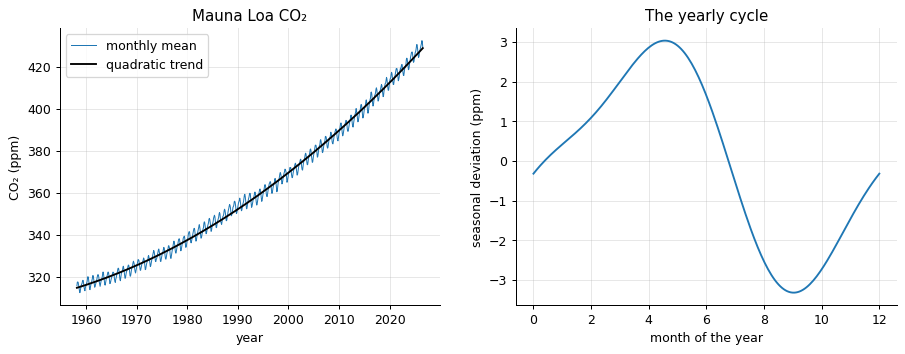

In [7]:
t, c = co2.decimal_year.to_numpy(), co2.co2_ppm.to_numpy()
tau = (t - 1990) / 10
X = np.column_stack([np.ones_like(t), tau, tau**2] + [f(2*np.pi*k*t) for k in (1, 2) for f in (np.sin, np.cos)])
fit = fitting.linear_lstsq(X, c)
trend = X[:, :3] @ fit.coef[:3]
seasonal = X[:, 3:] @ fit.coef[3:]
growth = lambda year: (fit.coef[1] + 2*fit.coef[2]*(year - 1990)/10) / 10      # d(trend)/dt in ppm per year
print(f"growth rate of the trend: {growth(1960):.2f} ppm/yr in 1960, {growth(2025):.2f} ppm/yr in 2025")
print(f"seasonal cycle: peak-to-peak {seasonal.max() - seasonal.min():.1f} ppm")
print(f"residual standard deviation: {fit.sigma:.2f} ppm")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(t, c, lw=0.8, label="monthly mean"); a1.plot(t, trend, "k", label="quadratic trend")
a1.set(xlabel="year", ylabel="CO₂ (ppm)", title="Mauna Loa CO₂"); a1.legend()
year_frac = np.linspace(0, 1, 200)
one_year = np.column_stack([f(2*np.pi*k*year_frac) for k in (1, 2) for f in (np.sin, np.cos)]) @ fit.coef[3:]
a2.plot(12 * year_frac, one_year)
a2.set(xlabel="month of the year", ylabel="seasonal deviation (ppm)", title="The yearly cycle")
plt.show()

The growth rate has roughly tripled since 1960, and CO₂ swings by several ppm each year as the northern
hemisphere's vegetation grows in summer and decays in winter.

Is the model adequate? The spectrum of the residuals (notebook 16; sampling frequency 12 per year)
checks whether any periodic signal was missed:

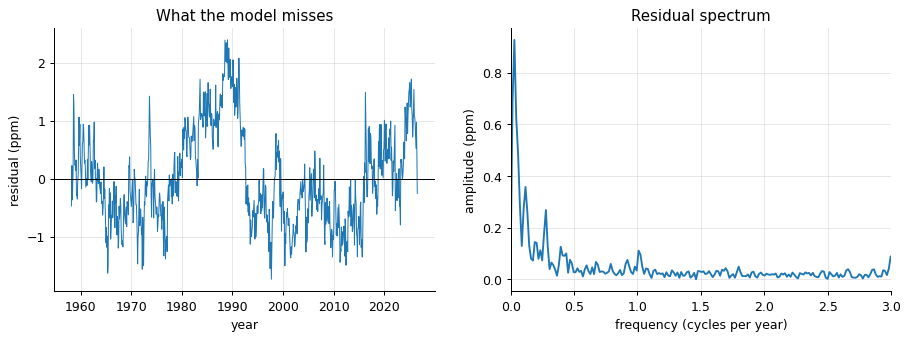

largest residual amplitude at 0.03 cycles per year (period 34 years)
residual amplitude at 1 cycle per year: 0.034 ppm (the fitted seasonal amplitude was about 3.1 ppm)


In [8]:
resid = c - X @ fit.coef
f, amp = fourier.spectrum(resid, fs=12.0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(t, resid, lw=0.8); a1.axhline(0, color="k", lw=0.8)
a1.set(xlabel="year", ylabel="residual (ppm)", title="What the model misses")
a2.plot(f, amp); a2.set(xlabel="frequency (cycles per year)", ylabel="amplitude (ppm)", xlim=(0, 3),
                        title="Residual spectrum")
plt.show()
print(f"largest residual amplitude at {f[np.argmax(amp)]:.2f} cycles per year (period {1/f[np.argmax(amp)]:.0f} years)")
print(f"residual amplitude at 1 cycle per year: {amp[np.argmin(abs(f - 1))]:.3f} ppm "
      f"(the fitted seasonal amplitude was about {(seasonal.max() - seasonal.min())/2:.1f} ppm)")

No yearly peak remains - the seasonal terms captured the cycle. What is left is slow wandering over
years to decades: the quadratic trend is only an approximation to the true growth curve. **Residual
plots tell you where a model is wrong; they are not an afterthought.**

## Rule 3: a messy file needs a documented cleaning procedure
Now a file of the kind data loggers really produce. Read the header lines first - they carry information
the table does not:

# Data logger DL-7 / reactor R2 / exported 2026-03-14 14:05
# Columns: timestamp, temperature, pressure
# Temperature unit: degF until 10:00, then logger reconfigured to degC
# Pressure unit: bar. Error code -999 = sensor fault. Empty field = no reading.

351 rows; column types:
timestamp      datetime64[us]
temperature           float64
pressure              float64
dtype: object


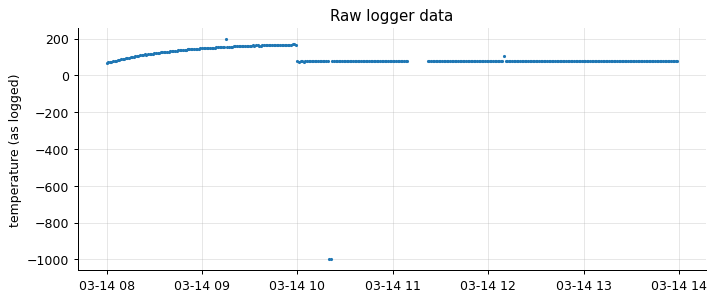

In [9]:
log_path = datasets.path("process_log_messy.csv")
with open(log_path, encoding="utf-8") as fh:
    for line in fh:
        if line.startswith("#"):
            print(line.rstrip())
raw = pd.read_csv(log_path, comment="#", parse_dates=["timestamp"])
print(f"\n{len(raw)} rows; column types:\n{raw.dtypes}")
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(raw.timestamp, raw.temperature, ".", ms=3); ax.set(ylabel="temperature (as logged)", title="Raw logger data")
plt.show()

The raw plot shows everything that is wrong: a jump at 10:00 (the unit change announced in the header),
error codes at -999, a few spikes, and a gap. Clean step by step, and **count what each step changes**.
Note how the spike threshold is chosen: the genuine spikes lie over a hundred robust standard deviations
from the running median, while ordinary points - even the steep start of the heat-up, where a running
median at the edge of the data is biased - stay well below 20. Look at the numbers before choosing a
threshold; a threshold that is too low deletes real data.

In [10]:
df = raw.copy()
log = []

n = len(df); df = df.drop_duplicates()
log.append(f"removed {n - len(df)} duplicated rows (retransmissions)")

bad = df.temperature == -999
df.loc[bad, "temperature"] = np.nan                        # BEFORE converting units: -999 degF is not a temperature
log.append(f"replaced {bad.sum()} sensor-fault codes (-999) by NaN")

before_10 = df.timestamp < pd.Timestamp("2026-03-14 10:00")
df.loc[before_10, "temperature"] = (df.loc[before_10, "temperature"] - 32) * 5 / 9
log.append(f"converted {before_10.sum()} readings from degF to degC")
df = df.rename(columns={"temperature": "temperature_degC", "pressure": "pressure_bar"})

med = df.temperature_degC.rolling(7, center=True, min_periods=3).median()
dev = df.temperature_degC - med
mad = 1.4826 * np.nanmedian(np.abs(dev))                   # robust estimate of the noise level
z = np.abs(dev) / mad
print("largest deviations, in robust standard deviations:", np.round(np.sort(z.dropna())[-4:], 1))
spikes = z > 20
df.loc[spikes, "temperature_degC"] = np.nan
log.append(f"removed {spikes.sum()} spikes (more than 20 robust standard deviations from the running median)")

def fill_short_gaps(s, max_len=3):
    # interpolate runs of at most max_len missing values; leave longer gaps empty
    missing = s.isna()
    run_id = missing.ne(missing.shift()).cumsum()
    run_length = missing.groupby(run_id).transform("sum")
    return s.where(~(missing & (run_length <= max_len)), s.interpolate(limit_area="inside"))

df = df.set_index("timestamp").resample("1min").mean()     # regular 1-minute grid; the gap becomes NaN rows
empty_before = df.temperature_degC.isna().sum()
df = df.apply(fill_short_gaps)
log.append(f"placed data on a 1-minute grid ({len(df)} rows); interpolated gaps of at most 3 minutes; "
           f"{df.temperature_degC.isna().sum()} of {empty_before} empty temperature slots left empty "
           f"(the 12 minutes the logger was offline)")
print("\n".join(f"{i}. {entry}" for i, entry in enumerate(log, 1)))

largest deviations, in robust standard deviations: [  7.   12.8 125.3 130.7]
1. removed 3 duplicated rows (retransmissions)
2. replaced 2 sensor-fault codes (-999) by NaN
3. converted 120 readings from degF to degC
4. removed 2 spikes (more than 20 robust standard deviations from the running median)
5. placed data on a 1-minute grid (360 rows); interpolated gaps of at most 3 minutes; 12 of 16 empty temperature slots left empty (the 12 minutes the logger was offline)


## Inside the algorithm: robust spike detection
A spike is a value far from its neighbours. The running **median** ignores a single wild value (a mean
would be dragged towards it), and the median absolute deviation (MAD, scaled by 1.4826 to match a
standard deviation for normal noise) measures the typical scatter without being inflated by the
spikes themselves:

In [11]:
values = np.array([50.1, 50.3, 49.9, 50.2, 75.0, 50.4, 50.1, 50.0])   # one spike
running_median = np.array([np.median(values[max(0, i-3):i+4]) for i in range(values.size)])
dev = values - running_median
robust_sd = 1.4826 * np.median(np.abs(dev))
print("deviation / robust SD:", np.round(dev / robust_sd, 1))
print(f"plain standard deviation {np.std(dev):.2f} (inflated by the spike) vs robust {robust_sd:.2f}")

deviation / robust SD: [-0.2  0.4 -1.3  0.  95.6  1.  -0.4 -1. ]
plain standard deviation 8.22 (inflated by the spike) vs robust 0.26


Two principles: **keep the raw file untouched** (all changes happen in code, which documents them), and
**never invent data across a long gap** - the 12 minutes the logger was offline stay empty.

Because this file is synthetic we can check the cleaning: it was generated from a heat-up curve
$T(t) = T_\infty - (T_\infty - T_0)\,e^{-t/\tau}$ with $T_0$ = 20 °C, $T_\infty$ = 80 °C and $\tau$ = 45 min.
Fitting that model (notebook 09) to raw and cleaned data:

raw data     : T0 =   62.78 °C, T_inf =  94.08 °C, tau =   4.39 min, residual SD  89.24 K
cleaned data : T0 =   19.96 °C, T_inf =  79.97 °C, tau =  45.06 min, residual SD   0.31 K
true values  : T0 =   20.00 °C, T_inf =  80.00 °C, tau =  45.00 min, noise SD 0.30 K


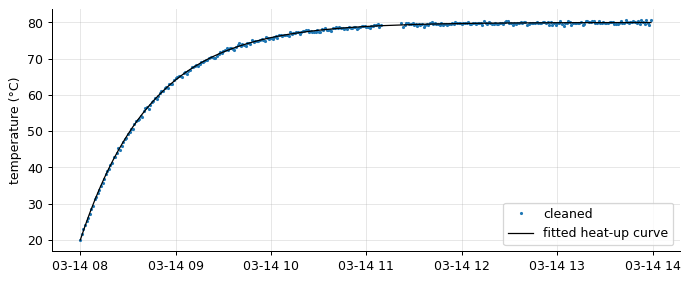

In [12]:
model = lambda tm, T0, Tinf, tau: Tinf - (Tinf - T0) * np.exp(-tm / tau)
ok = df.temperature_degC.notna()
minutes = (df.index[ok] - df.index[0]).total_seconds().to_numpy() / 60
clean_fit = fitting.levenberg_marquardt(model, minutes, df.temperature_degC[ok].to_numpy(), [25, 75, 30])
raw_ok = raw.temperature.notna()
raw_minutes = (raw.timestamp[raw_ok] - raw.timestamp.iloc[0]).dt.total_seconds().to_numpy() / 60
raw_fit = fitting.levenberg_marquardt(model, raw_minutes, raw.temperature[raw_ok].to_numpy(), [25, 75, 30])
for name, fr in (("raw data", raw_fit), ("cleaned data", clean_fit)):
    T0f, Tinff, tauf = fr.coef
    print(f"{name:<13}: T0 = {T0f:7.2f} °C, T_inf = {Tinff:6.2f} °C, tau = {tauf:6.2f} min, residual SD {fr.sigma:6.2f} K")
print("true values  : T0 =   20.00 °C, T_inf =  80.00 °C, tau =  45.00 min, noise SD 0.30 K")
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(df.index, df.temperature_degC, ".", ms=3, label="cleaned")
ax.plot(df.index[ok], model(minutes, *clean_fit.coef), "k", lw=1, label="fitted heat-up curve")
ax.set(ylabel="temperature (°C)"); ax.legend(); plt.show()

Without cleaning, the fitted parameters are meaningless. After cleaning they agree with the values used
to generate the file, and the residual standard deviation equals the sensor noise.

## Saving results
Put units in column names, write the cleaning log next to the data, and keep the raw file as it was:

In [13]:
import tempfile
from pathlib import Path
out_dir = Path(tempfile.gettempdir())
df.to_csv(out_dir / "process_log_clean.csv", float_format="%.3f")
(out_dir / "process_log_clean_README.txt").write_text("Cleaning steps:\n" + "\n".join(log), encoding="utf-8")
print(open(out_dir / "process_log_clean.csv", encoding="utf-8").read()[:230])

timestamp,temperature_degC,pressure_bar
2026-03-14 08:00:00,19.894,1.994
2026-03-14 08:01:00,21.678,2.006
2026-03-14 08:02:00,23.028,2.010
2026-03-14 08:03:00,23.967,2.019
2026-03-14 08:04:00,25.228,2.029
2026-03-14 08:05:00,26.16


## Checklist for any data file
1. Open it as text and read the header, comments and documentation.
2. Check shapes, column types, ranges and units - and whether labels match the values.
3. Plot the raw data before doing anything else.
4. Clean in code, step by step, recording what each step changed. Never edit the raw file.
5. Treat missing values explicitly; do not fill long gaps.
6. Plot again, and check residuals of any model you fit.

## Exercises
1. **Copper's thermal expansion.** Read `Hahn1.dat` (NIST, real). Plot the coefficient of thermal
   expansion against temperature. Fit the certified 7-parameter rational model
   $y = (b_1 + b_2x + b_3x^2 + b_4x^3)/(1 + b_5x + b_6x^2 + b_7x^3)$ from NIST's first starting values (in
   the file) and compare with the certified values.
2. **El Niño.** Read `ENSO.dat` (NIST, real: monthly pressure differences between Easter Island and
   Darwin). Compute its spectrum. Besides the annual cycle, at which periods (in months) are there
   peaks? Compare with the certified periods $b_4$ and $b_7$ in the file header.
3. Extrapolate the CO₂ trend to find when the trend first exceeds 450 ppm. Refit using only data up to
   2000 and extrapolate again: how far off would that forecast have been for 2026? What does this say
   about extrapolating fitted trends?
4. **Implement it yourself:** write `read_nist(name)` that returns the data, the certified values and their standard deviations for any NIST StRD file, by finding the line that starts with `Data:` and the lines containing `b1 =`, `b2 =`, ... instead of hard-coding `skiprows=60`. Test it on all three NIST files.